In [1]:
import numpy as np
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import parafac
import tensorly as tl

In [2]:
# Define the function to be tested
def f(x, y, c = 5):
    return 1/( 1 + c**2 * (x**2 + y**2))

Rank 1, RMSE: 2.12e-02, MaxE: 1.18e-01
Rank 2, RMSE: 3.97e-03, MaxE: 2.26e-02
Rank 3, RMSE: 6.38e-04, MaxE: 3.21e-03
Rank 4, RMSE: 1.00e-04, MaxE: 5.47e-04
Rank 5, RMSE: 1.57e-05, MaxE: 6.32e-05
Rank 6, RMSE: 2.45e-06, MaxE: 1.46e-05
Rank 7, RMSE: 3.81e-07, MaxE: 2.35e-06
Rank 8, RMSE: 5.88e-08, MaxE: 3.06e-07
Rank 9, RMSE: 8.76e-09, MaxE: 4.79e-08
Rank 10, RMSE: 1.21e-09, MaxE: 6.86e-09


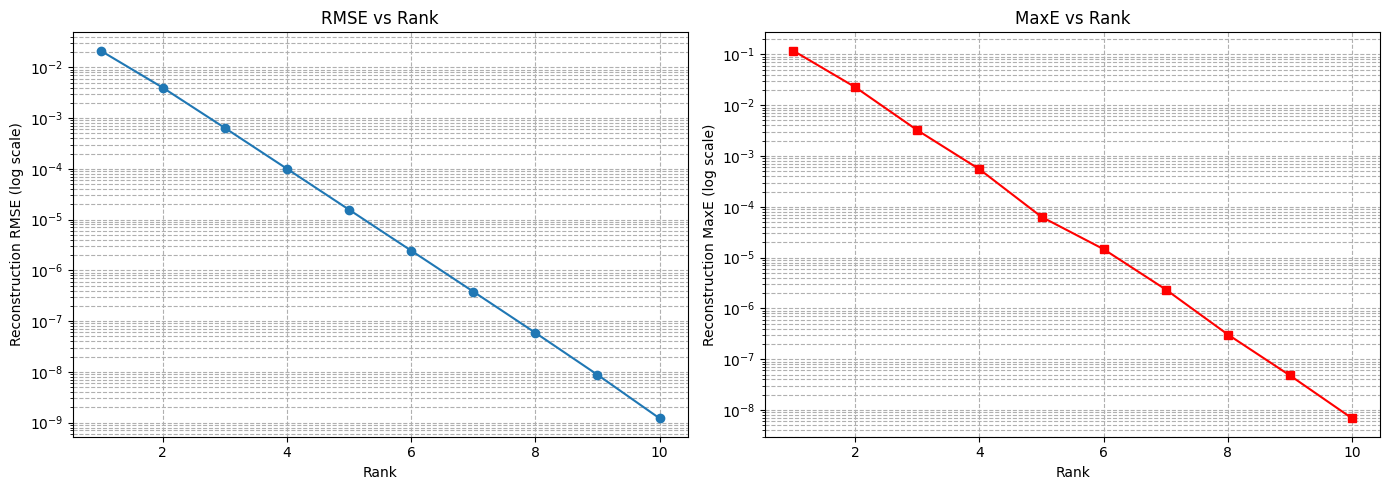

In [3]:
# CP decomposition and error analysis:

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import parafac
import tensorly as tl

# Define the function to be tested
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Chebyshev nodes
N, M = 64, 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

# Sample the function
F = np.vectorize(lambda x, y: f(x, y))(X, Y)

# Set TensorLy backend
tl.set_backend('numpy')

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []
F_reconstructed_list = []

# Iterate over ranks
for rank in ranks:
    cp_tensor = parafac(F, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A, B = factors  # A: (N, R), B: (M, R)

    # Fit each column of A and B to Chebyshev basis
    A_cheb = np.array([chebfit(x_nodes, A[:, r], deg=N - 1) for r in range(rank)]).T
    B_cheb = np.array([chebfit(y_nodes, B[:, r], deg=M - 1) for r in range(rank)]).T

    # Reconstruct tensor
    F_reconstructed = np.zeros((N, M))
    for r in range(rank):
        F_reconstructed += weights[r] * np.outer(
            chebval(x_nodes, A_cheb[:, r]), chebval(y_nodes, B_cheb[:, r])
        )
    F_reconstructed_list.append(F_reconstructed)

    # Compute RMSE and MaxE
    diff = F - F_reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Create side-by-side plots for RMSE and MaxE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("Reconstruction RMSE (log scale)")
axs[0].set_title("RMSE vs Rank")
axs[0].grid(True, which='both', linestyle='--')

# Plot MaxE
axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("Reconstruction MaxE (log scale)")
axs[1].set_title("MaxE vs Rank")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


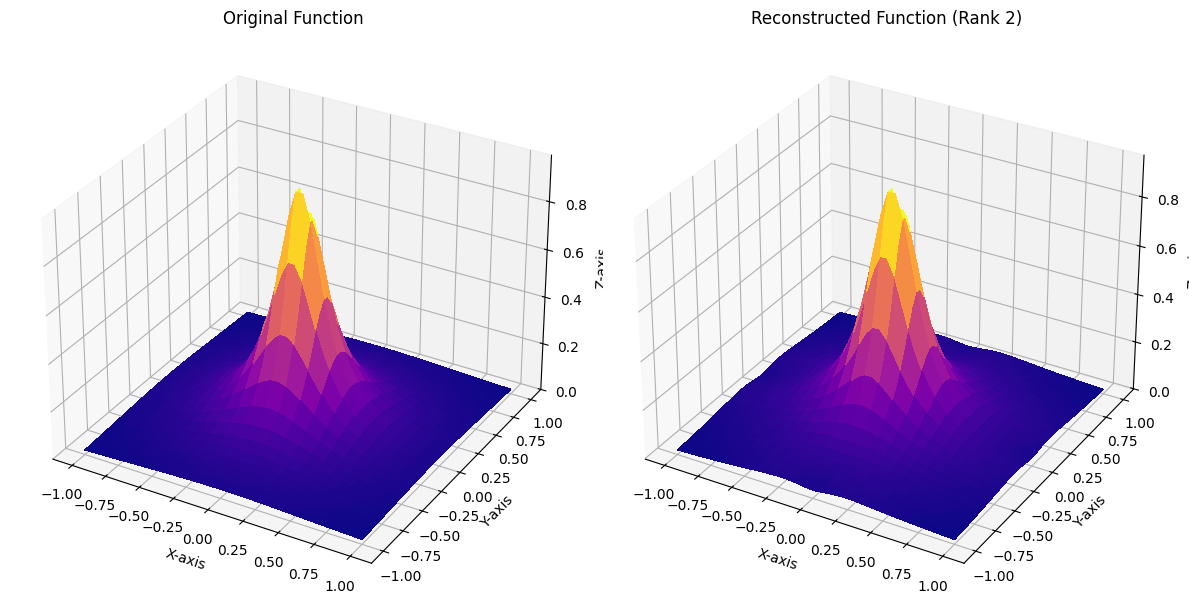

In [4]:
from matplotlib import cm

rank = 2  # Choose the rank you want to visualize
F_approx = F_reconstructed_list[rank - 1]

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.plasma, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_approx, cmap=cm.plasma, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


/Users/loadedguns/Downloads/Research/Tensor_research/.venv/lib/python3.13/site-packages/tensorly/tucker_tensor.py:432: RuntimeWarning: Given only one int for 'rank' for decomposition a tensor of order 2. Using this rank for all modes.
  warnings.warn(message, RuntimeWarning)


Rank 1, RMSE: 2.12e-02, MaxE: 1.18e-01
Rank 2, RMSE: 3.97e-03, MaxE: 2.26e-02
Rank 3, RMSE: 6.38e-04, MaxE: 3.21e-03
Rank 4, RMSE: 1.00e-04, MaxE: 5.47e-04
Rank 5, RMSE: 1.57e-05, MaxE: 6.32e-05
Rank 6, RMSE: 2.45e-06, MaxE: 1.46e-05
Rank 7, RMSE: 3.81e-07, MaxE: 2.35e-06
Rank 8, RMSE: 5.88e-08, MaxE: 3.06e-07
Rank 9, RMSE: 8.76e-09, MaxE: 4.79e-08
Rank 10, RMSE: 1.21e-09, MaxE: 6.86e-09


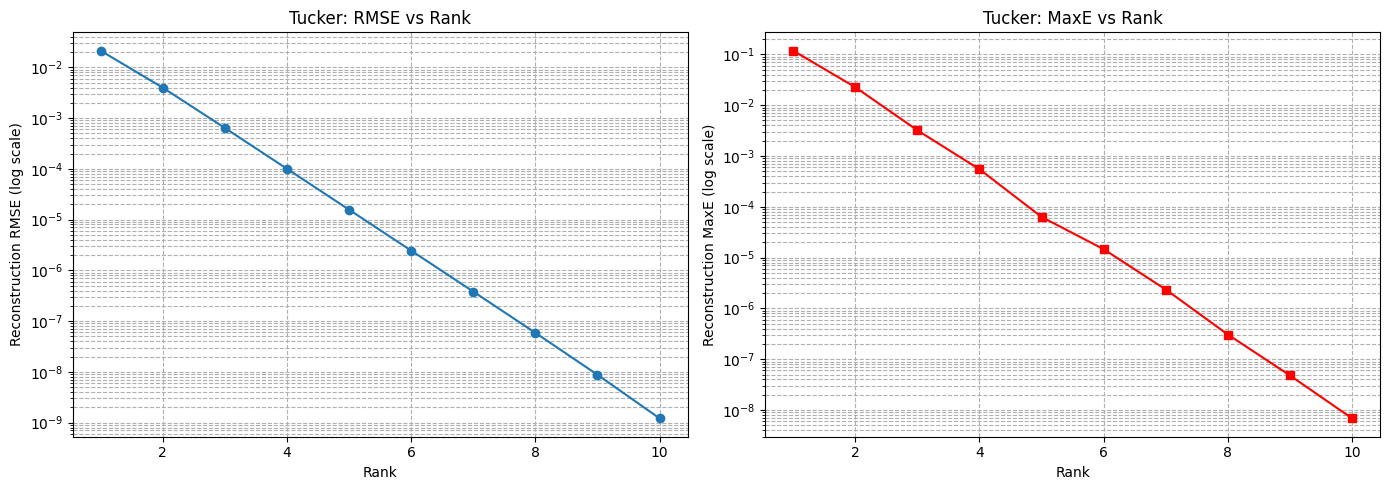

In [5]:
# Tucker decomposition and error analysis:

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import tucker
import tensorly as tl

# Define the function to be tested
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Chebyshev nodes
N, M = 64, 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

# Sample the function
F = np.vectorize(lambda x, y: f(x, y))(X, Y)

# Set TensorLy backend
tl.set_backend('numpy')

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []
F_reconstructed_list = []

# Iterate over ranks
for rank in ranks:
    # Perform Tucker decomposition
    core, factors = tucker(F, rank)
    A, B = factors  # A: (N, rank), B: (M, rank)

    # Fit each column of A and B to Chebyshev basis
    A_cheb = np.array([chebfit(x_nodes, A[:, i], deg=N - 1) for i in range(rank)]).T
    B_cheb = np.array([chebfit(y_nodes, B[:, j], deg=M - 1) for j in range(rank)]).T

    # Reconstruct the tensor
    F_reconstructed = np.zeros((N, M))
    for i in range(rank):
        for j in range(rank):
            outer = np.outer(
                chebval(x_nodes, A_cheb[:, i]),
                chebval(y_nodes, B_cheb[:, j])
            )
            F_reconstructed += core[i, j] * outer
    F_reconstructed_list.append(F_reconstructed)

    # Compute RMSE and MaxE
    diff = F - F_reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Create side-by-side plots for RMSE and MaxE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("Reconstruction RMSE (log scale)")
axs[0].set_title("Tucker: RMSE vs Rank")
axs[0].grid(True, which='both', linestyle='--')

# Plot MaxE
axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("Reconstruction MaxE (log scale)")
axs[1].set_title("Tucker: MaxE vs Rank")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


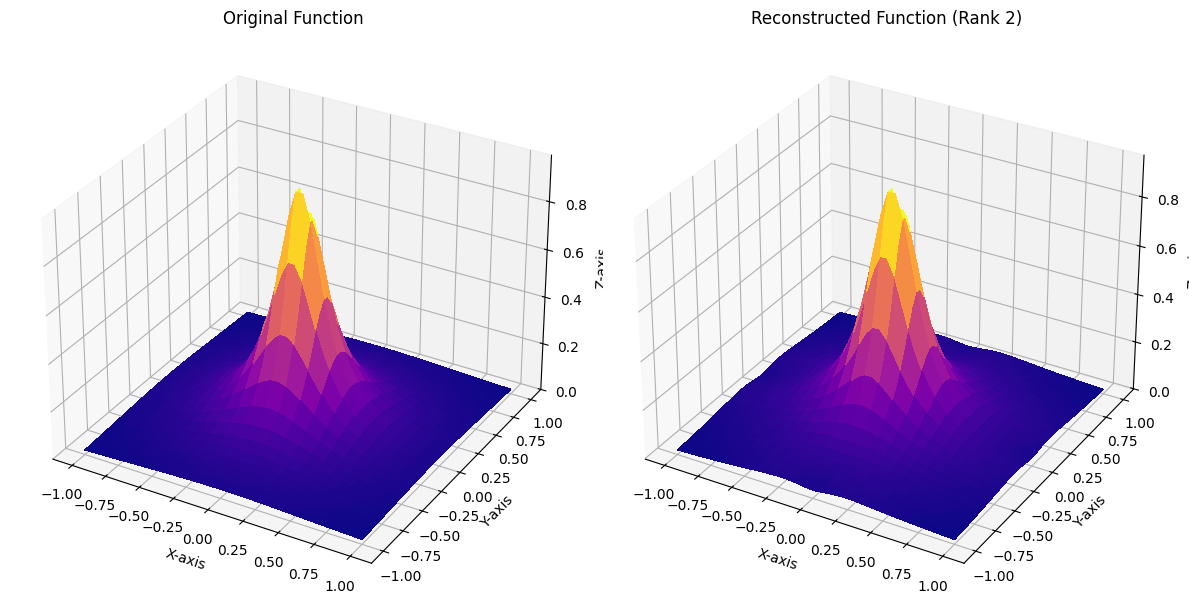

In [6]:
rank = 2  # Choose the rank you want to visualize
F_approx = F_reconstructed_list[rank - 1]

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.plasma, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_approx, cmap=cm.plasma, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()

Rank 1, RMSE: 2.50e-02, MaxE: 1.70e-01
Rank 2, RMSE: 4.17e-03, MaxE: 2.40e-02
Rank 3, RMSE: 8.44e-04, MaxE: 6.69e-03
Rank 4, RMSE: 1.25e-04, MaxE: 1.34e-03
Rank 5, RMSE: 2.52e-05, MaxE: 1.84e-04
Rank 6, RMSE: 2.94e-06, MaxE: 2.58e-05
Rank 7, RMSE: 4.02e-07, MaxE: 2.01e-06
Rank 8, RMSE: 6.78e-08, MaxE: 3.48e-07
Rank 9, RMSE: 1.07e-08, MaxE: 7.69e-08
Rank 10, RMSE: 1.55e-09, MaxE: 1.25e-08


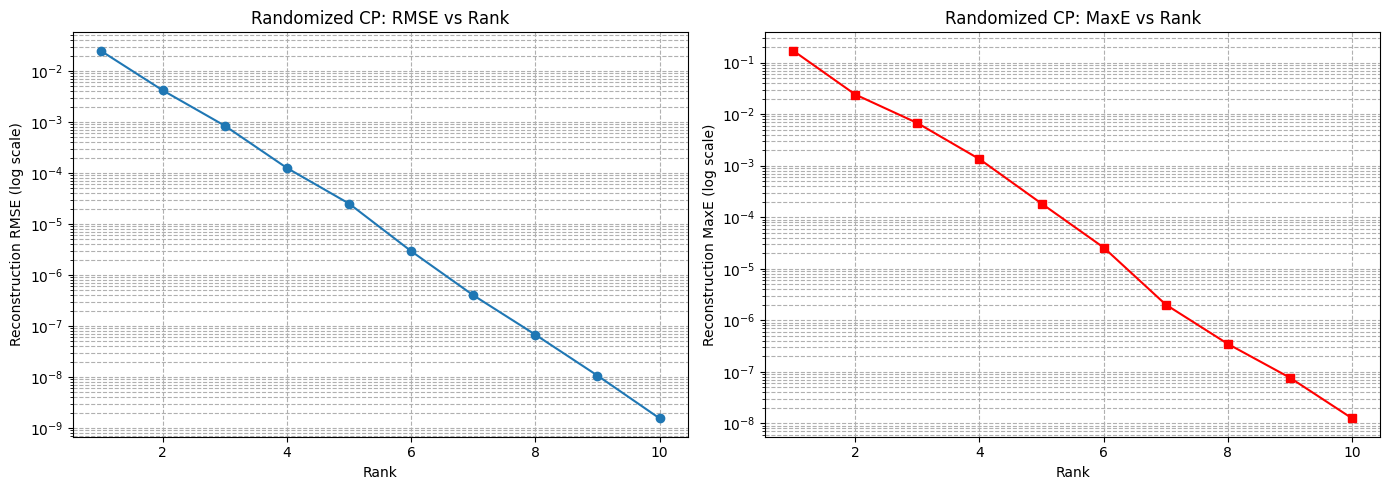

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import randomised_parafac
import tensorly as tl

# Define the function to be tested
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Chebyshev nodes
N, M = 64, 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

# Sample the function
F = np.vectorize(lambda x, y: f(x, y))(X, Y)

# Set TensorLy backend
tl.set_backend('numpy')

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []
F_reconstructed_list = []

# Iterate over ranks
for rank in ranks:
    # NOTE: Tunable parameters are available in randomised_parafac
    factors = randomised_parafac(F, rank, n_samples=10*rank)
    A, B = factors.factors

    # Fit each column of A and B to Chebyshev basis
    A_cheb = np.array([chebfit(x_nodes, A[:, r], deg=N - 1) for r in range(rank)]).T
    B_cheb = np.array([chebfit(y_nodes, B[:, r], deg=M - 1) for r in range(rank)]).T

    # Reconstruct tensor (note: no weights, assume all 1)
    F_reconstructed = np.zeros((N, M))
    for r in range(rank):
        F_reconstructed += np.outer(
            chebval(x_nodes, A_cheb[:, r]), 
            chebval(y_nodes, B_cheb[:, r])
        )
    F_reconstructed_list.append(F_reconstructed)

    # Compute RMSE and MaxE
    diff = F - F_reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Create side-by-side plots for RMSE and MaxE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("Reconstruction RMSE (log scale)")
axs[0].set_title("Randomized CP: RMSE vs Rank")
axs[0].grid(True, which='both', linestyle='--')

# Plot MaxE
axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("Reconstruction MaxE (log scale)")
axs[1].set_title("Randomized CP: MaxE vs Rank")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


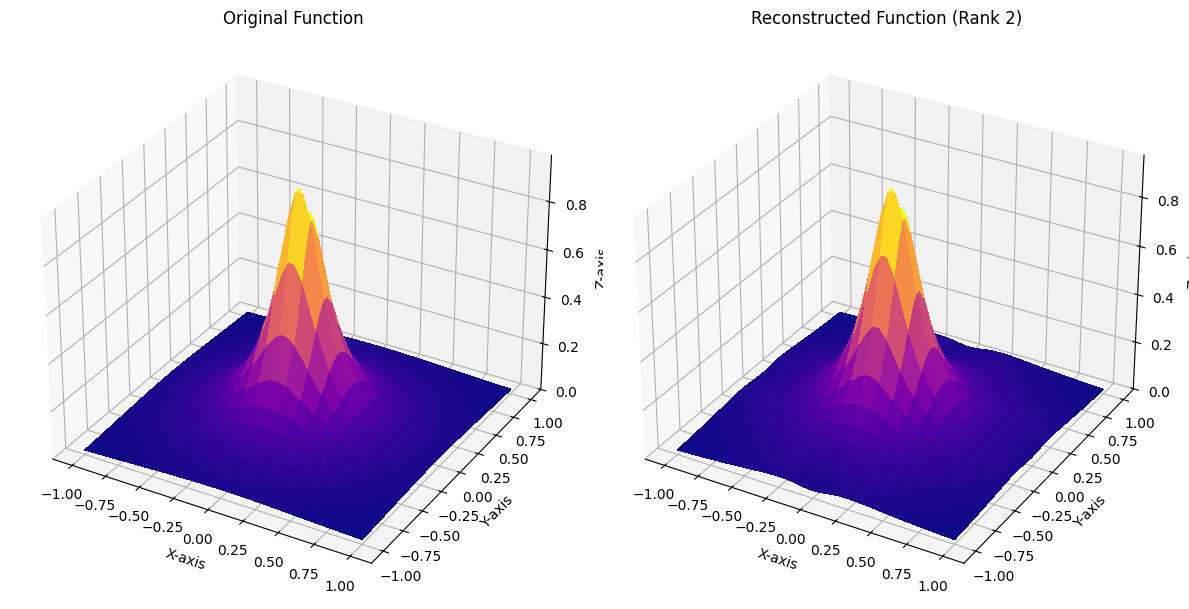

In [8]:
rank = 2  # Choose the rank you want to visualize
F_approx = F_reconstructed_list[rank - 1]

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.plasma, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_approx, cmap=cm.plasma, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()

Rank 1, RMSE: 2.12e-02, MaxE: 1.18e-01
Rank 2, RMSE: 3.97e-03, MaxE: 2.26e-02
Rank 3, RMSE: 6.38e-04, MaxE: 3.21e-03
Rank 4, RMSE: 1.00e-04, MaxE: 5.47e-04
Rank 5, RMSE: 1.57e-05, MaxE: 6.32e-05
Rank 6, RMSE: 2.45e-06, MaxE: 1.46e-05
Rank 7, RMSE: 3.81e-07, MaxE: 2.35e-06
Rank 8, RMSE: 5.88e-08, MaxE: 3.06e-07
Rank 9, RMSE: 8.76e-09, MaxE: 4.79e-08
Rank 10, RMSE: 1.21e-09, MaxE: 6.86e-09


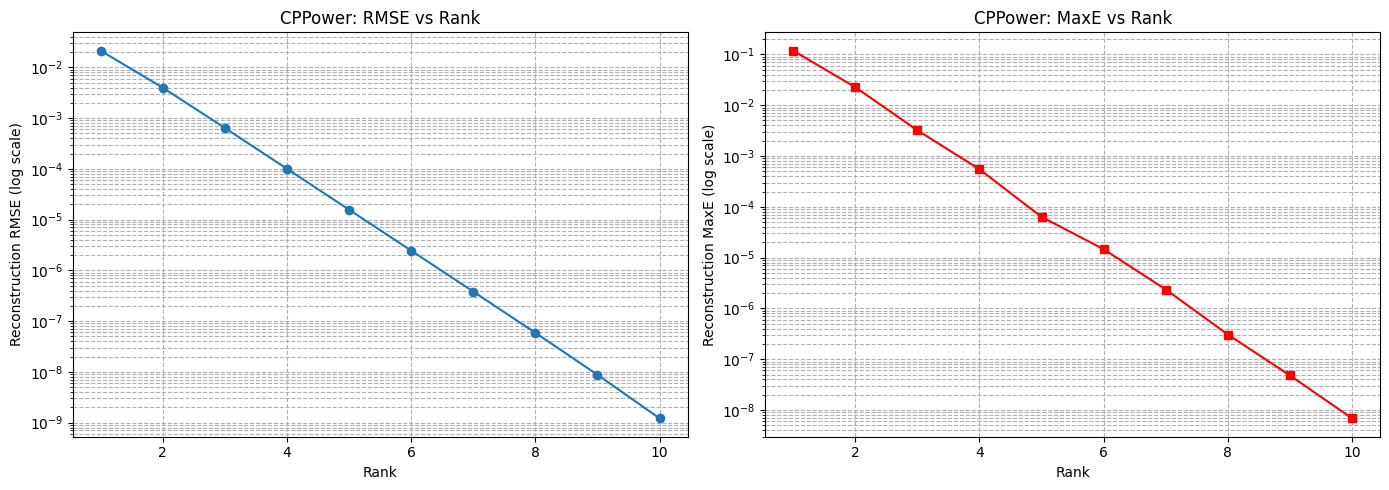

In [9]:
# CP Power decomposition and error analysis:

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import CPPower
import tensorly as tl

# Define the function to be tested
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Chebyshev nodes
N, M = 64, 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

# Sample the function
F = np.vectorize(lambda x, y: f(x, y))(X, Y)

# Set TensorLy backend
tl.set_backend('numpy')

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []
F_reconstructed_list = []

# Iterate over ranks
for rank in ranks:
    # Perform CP decomposition using CPPower
    model = CPPower(rank=rank, n_repeat=10, n_iteration=20, verbose=0)
    weights, (A, B) = model.fit_transform(F)

    # Fit each column of A and B to Chebyshev basis
    A_cheb = np.array([chebfit(x_nodes, A[:, r], deg=N - 1) for r in range(rank)]).T
    B_cheb = np.array([chebfit(y_nodes, B[:, r], deg=M - 1) for r in range(rank)]).T

    # Reconstruct tensor using weights
    F_reconstructed = np.zeros((N, M))
    for r in range(rank):
        col_A = chebval(x_nodes, A_cheb[:, r])
        col_B = chebval(y_nodes, B_cheb[:, r])
        F_reconstructed += weights[r] * np.outer(col_A, col_B)

    F_reconstructed_list.append(F_reconstructed)

    # Compute RMSE and MaxE
    diff = F - F_reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Create side-by-side plots for RMSE and MaxE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("Reconstruction RMSE (log scale)")
axs[0].set_title("CPPower: RMSE vs Rank")
axs[0].grid(True, which='both', linestyle='--')

# Plot MaxE
axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("Reconstruction MaxE (log scale)")
axs[1].set_title("CPPower: MaxE vs Rank")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


TT Decomposition, RMSE: 4.44e-16, MaxE: 2.58e-15


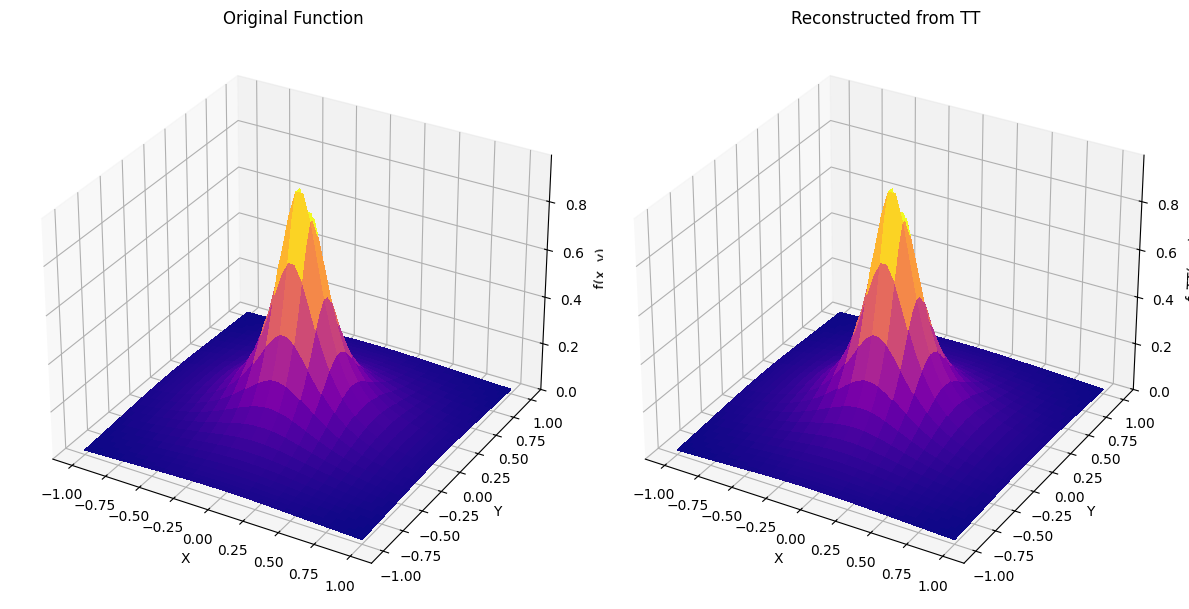

In [10]:
# TT Decomposition and error analysis:

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import TensorTrain
from tensorly.tt_tensor import tt_to_tensor
import tensorly as tl

# Set backend
tl.set_backend('numpy')

# Define function
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Chebyshev nodes
N, M = 64, 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')

# Sample function
F = np.vectorize(lambda x, y: f(x, y))(X, Y)

# Reshape to tensor format for TT decomposition
# E.g., reshape (64, 64) into (8, 8, 8, 8)
F_tensorized = F.reshape((8, 8, 8, 8))  # Make sure the reshape is valid

# Define TT-rank settings
tt_rank = 'same'

# Decompose
tt_model = TensorTrain(rank=tt_rank, verbose=False)
tt_cores = tt_model.fit_transform(F_tensorized)

# Reconstruct
F_reconstructed_tensorized = tt_to_tensor(tt_cores)

# Reshape back to original shape
F_reconstructed = F_reconstructed_tensorized.reshape((N, M))

# Compute errors
diff = F - F_reconstructed
rmse = np.sqrt(np.mean(diff**2))
maxe = np.max(np.abs(diff))

# Print results
print(f"TT Decomposition, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot original and reconstructed function
fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap='plasma', linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x, y)')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_reconstructed, cmap='plasma', linewidth=0, antialiased=False)
ax2.set_title('Reconstructed from TT')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('f_TT(x, y)')

plt.tight_layout()
plt.show()


Rank 1, RMSE: 1.56e-02, MaxE: 4.32e-01
Rank 2, RMSE: 3.19e-03, MaxE: 1.13e-01
Rank 3, RMSE: 2.53e-03, MaxE: 8.74e-02
Rank 4, RMSE: 5.25e-04, MaxE: 1.78e-02
Rank 5, RMSE: 4.97e-04, MaxE: 1.58e-02
Rank 6, RMSE: 2.56e-04, MaxE: 2.47e-03
Rank 7, RMSE: 4.34e-04, MaxE: 1.50e-02
Rank 8, RMSE: 3.00e-04, MaxE: 9.20e-03
Rank 9, RMSE: 1.73e-04, MaxE: 4.41e-03
Rank 10, RMSE: 8.64e-05, MaxE: 2.53e-03


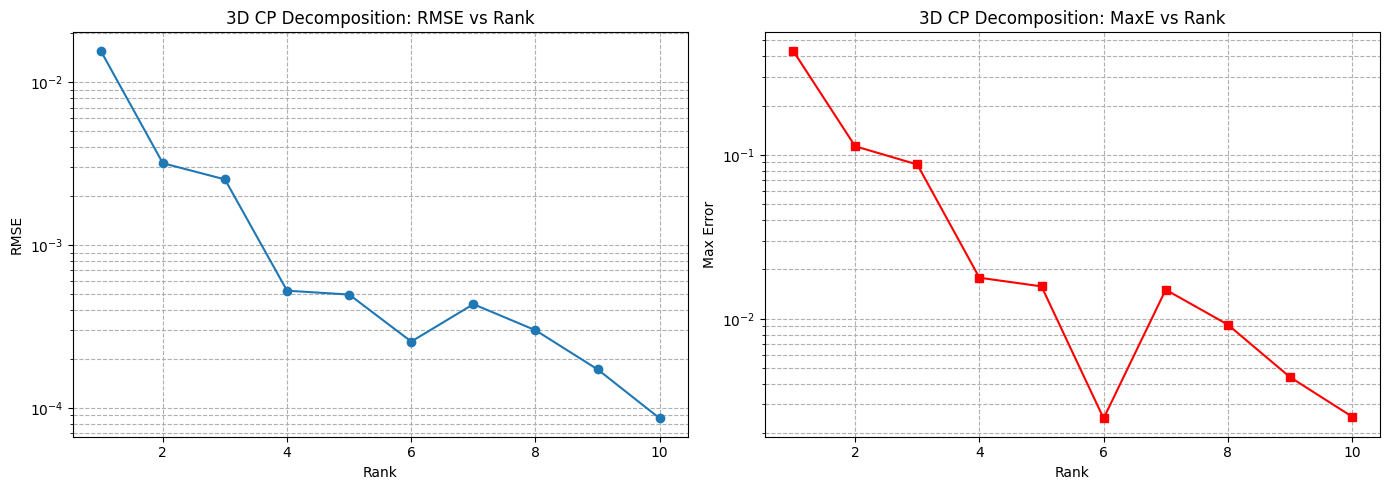

In [11]:
# CP decomposition and error analysis: IN 3D

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import parafac
import tensorly as tl

# Set TensorLy backend
tl.set_backend('numpy')

# Define the 3D function
def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

# Chebyshev nodes in each dimension
N = 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
z_nodes = np.cos(np.pi * np.arange(N) / (N - 1))

# Create 3D grid
X, Y, Z = np.meshgrid(x_nodes, y_nodes, z_nodes, indexing='ij')

# Evaluate the function over the grid
F = f(X, Y, Z)  # shape: (N, N, N)

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []

# Iterate over ranks
for rank in ranks:
    cp_tensor = parafac(F, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A, B, C = factors  # Each of shape (N, rank)

    # Fit each column of A, B, C to Chebyshev polynomials
    A_cheb = np.array([chebfit(x_nodes, A[:, r], deg=N - 1) for r in range(rank)]).T
    B_cheb = np.array([chebfit(y_nodes, B[:, r], deg=N - 1) for r in range(rank)]).T
    C_cheb = np.array([chebfit(z_nodes, C[:, r], deg=N - 1) for r in range(rank)]).T

    # Reconstruct the tensor
    F_reconstructed = np.zeros((N, N, N))
    for r in range(rank):
        u = chebval(x_nodes, A_cheb[:, r])
        v = chebval(y_nodes, B_cheb[:, r])
        w = chebval(z_nodes, C_cheb[:, r])
        F_reconstructed += weights[r] * np.einsum('i,j,k->ijk', u, v, w)

    # Compute RMSE and MaxE
    diff = F - F_reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot RMSE and MaxE vs Rank
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_yscale('log')
axs[0].set_xlabel('Rank')
axs[0].set_ylabel('RMSE')
axs[0].set_title('3D CP Decomposition: RMSE vs Rank')
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_yscale('log')
axs[1].set_xlabel('Rank')
axs[1].set_ylabel('Max Error')
axs[1].set_title('3D CP Decomposition: MaxE vs Rank')
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


/Users/loadedguns/Downloads/Research/Tensor_research/.venv/lib/python3.13/site-packages/tensorly/tucker_tensor.py:432: RuntimeWarning: Given only one int for 'rank' for decomposition a tensor of order 3. Using this rank for all modes.
  warnings.warn(message, RuntimeWarning)


Rank 1, RMSE: 1.56e-02, MaxE: 4.32e-01
Rank 2, RMSE: 3.19e-03, MaxE: 1.13e-01
Rank 3, RMSE: 5.87e-04, MaxE: 2.22e-02
Rank 4, RMSE: 1.07e-04, MaxE: 3.94e-03
Rank 5, RMSE: 1.93e-05, MaxE: 6.41e-04
Rank 6, RMSE: 3.40e-06, MaxE: 9.35e-05
Rank 7, RMSE: 5.87e-07, MaxE: 1.27e-05
Rank 8, RMSE: 1.01e-07, MaxE: 1.93e-06
Rank 9, RMSE: 1.72e-08, MaxE: 3.05e-07
Rank 10, RMSE: 2.87e-09, MaxE: 4.46e-08


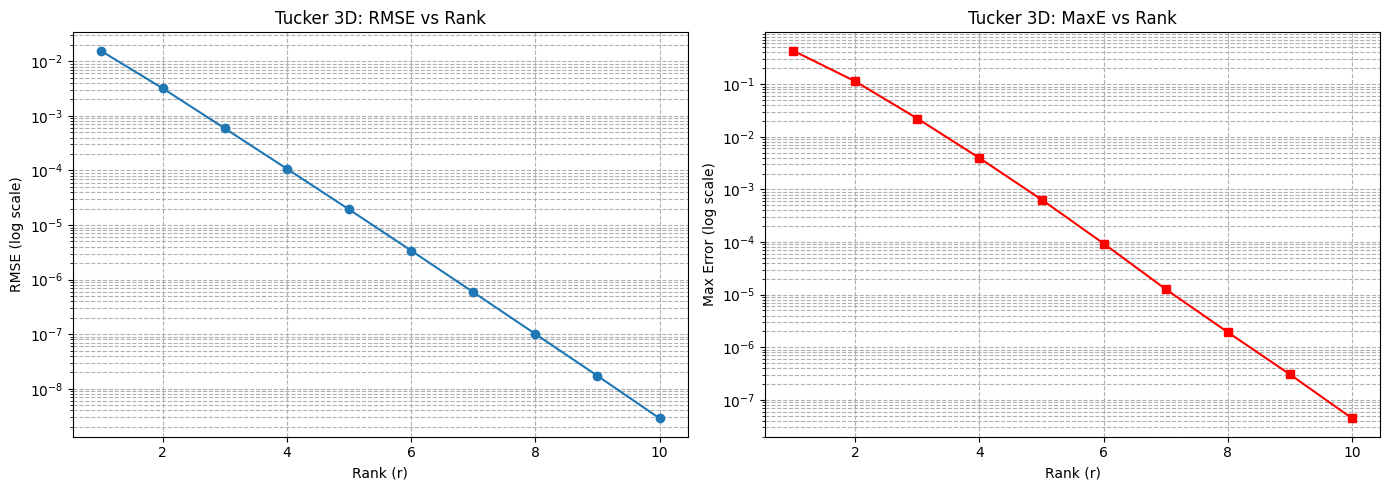

In [12]:
# Tucker decomposition and error analysis: IN 3D

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import tucker
import tensorly as tl

# Set backend
tl.set_backend('numpy')

# Define the 3D function
def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

# Chebyshev nodes
N = 64
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
z_nodes = np.cos(np.pi * np.arange(N) / (N - 1))

# Create 3D grid
X, Y, Z = np.meshgrid(x_nodes, y_nodes, z_nodes, indexing='ij')

# Evaluate function on grid
F = f(X, Y, Z)  # Shape: (N, N, N)

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []

# Iterate over Tucker ranks
for rank in ranks:
    # Tucker decomposition with rank (r, r, r)
    core, factors = tucker(F, rank)
    A, B, C = factors  # Each: (N, rank)

    # Fit Chebyshev polynomials to each factor matrix
    A_cheb = np.array([chebfit(x_nodes, A[:, i], deg=N-1) for i in range(rank)]).T
    B_cheb = np.array([chebfit(y_nodes, B[:, j], deg=N-1) for j in range(rank)]).T
    C_cheb = np.array([chebfit(z_nodes, C[:, k], deg=N-1) for k in range(rank)]).T

    # Reconstruct the tensor
    F_reconstructed = np.zeros((N, N, N))
    for i in range(rank):
        u = chebval(x_nodes, A_cheb[:, i])
        for j in range(rank):
            v = chebval(y_nodes, B_cheb[:, j])
            for k in range(rank):
                w = chebval(z_nodes, C_cheb[:, k])
                outer = np.einsum('i,j,k->ijk', u, v, w)
                F_reconstructed += core[i, j, k] * outer

    # Compute RMSE and MaxE
    diff = F - F_reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot RMSE and MaxE vs Rank
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# RMSE plot
axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank (r)")
axs[0].set_ylabel("RMSE (log scale)")
axs[0].set_title("Tucker 3D: RMSE vs Rank")
axs[0].grid(True, which='both', linestyle='--')

# Max Error plot
axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank (r)")
axs[1].set_ylabel("Max Error (log scale)")
axs[1].set_title("Tucker 3D: MaxE vs Rank")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()



TT Decomposition (64x64x64), RMSE: 7.64e-16, MaxE: 1.56e-13


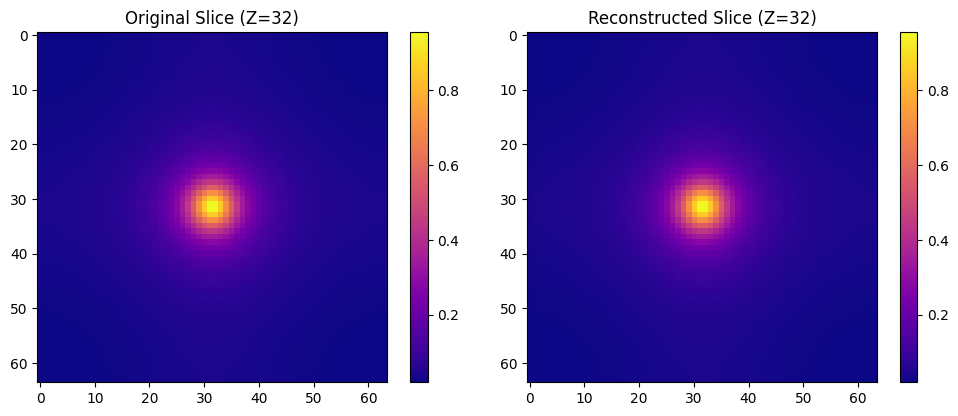

In [13]:
# TT Decomposition and error analysis: IN 3D

import numpy as np
import matplotlib.pyplot as plt
import tensorly as tl
from tensorly.decomposition import TensorTrain
from tensorly.tt_tensor import tt_to_tensor

tl.set_backend('numpy')

def f(x, y, z, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2 + z**2))

N = 64
nodes = np.cos(np.pi * np.arange(N) / (N - 1))
X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing='ij')

F = np.vectorize(f)(X, Y, Z)
F_tensorized = F.reshape((8, 8, 8, 8, 8, 8))

tt_rank = 'same'
tt_model = TensorTrain(rank=tt_rank, verbose=False)
tt_cores = tt_model.fit_transform(F_tensorized)

F_reconstructed_tensorized = tt_to_tensor(tt_cores)
F_reconstructed = F_reconstructed_tensorized.reshape((N, N, N))

diff = F - F_reconstructed
rmse = np.sqrt(np.mean(diff**2))
maxe = np.max(np.abs(diff))

print(f"TT Decomposition (64x64x64), RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(F[:, :, N//2], cmap='plasma')
plt.title('Original Slice (Z=32)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(F_reconstructed[:, :, N//2], cmap='plasma')
plt.title('Reconstructed Slice (Z=32)')
plt.colorbar()

plt.tight_layout()
plt.show()
